# Titanic EDA — In-Class Exercise (Answer Key)

Solutions for `02_titanic_eda_exercise.ipynb`. Uses `titanic_df` consistently throughout (the original demo notebook accidentally switched to an undefined `df` partway through — that's the naming bug from the earlier error discussion, fixed here).

Dataset: Titanic passenger records, loaded from a CSV of real historical data.

## 1. Load and inspect the data

1. Import `pandas` as `pd`.
2. Load the CSV at `https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/datafiles-titanic.csv` into a DataFrame called `titanic_df`.
3. Print the shape of `titanic_df` (rows, columns).
4. Use `.info()` to check column types and missing values.
5. List the column names.
6. Print the dtype of each column.

In [3]:
import pandas as pd


In [4]:
titanic_df = pd.read_csv('https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/datafiles-titanic.csv')


In [5]:
titanic_df.shape


(891, 9)

In [6]:
titanic_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   passenger_id  891 non-null    str    
 1   survived      891 non-null    int64  
 2   sex           891 non-null    str    
 3   age           714 non-null    float64
 4   sibsp         891 non-null    int64  
 5   parch         891 non-null    int64  
 6   fare          891 non-null    float64
 7   class         891 non-null    str    
 8   embark_town   889 non-null    str    
dtypes: float64(2), int64(3), str(4)
memory usage: 62.8 KB


In [7]:
titanic_df.columns


Index(['passenger_id', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'class', 'embark_town'],
      dtype='str')

In [8]:
titanic_df.dtypes


passenger_id        str
survived          int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
class               str
embark_town         str
dtype: object

## 2. Data quality checks

Before doing any real analysis, check how clean the data actually is — this is a step the demo notebook skipped, and it matters.

1. Count the missing values in every column (Hint: `.isna().sum()`). Which columns have gaps?
2. What *percentage* of `age` values are missing? (Hint: divide the count from step 1 by `len(titanic_df)` and multiply by 100.)
3. Check for exact duplicate rows (Hint: `.duplicated().sum()`). If you find any, add a comment saying whether you'd drop them and why.

`age` is missing for ~20% of passengers and `embark_town` is missing for 2 — both small enough to keep and handle per-analysis (e.g. `.dropna()` when needed) rather than dropping rows outright. There are no exact duplicate rows, so nothing to remove there.

In [9]:
titanic_df.isna().sum()


passenger_id      0
survived          0
sex               0
age             177
sibsp             0
parch             0
fare              0
class             0
embark_town       2
dtype: int64

In [10]:
pct_age_missing = titanic_df['age'].isna().sum() / len(titanic_df) * 100
print(f"{pct_age_missing:.1f}% of age values are missing")


19.9% of age values are missing


In [11]:
# No duplicate rows found -- nothing to drop here.
titanic_df.duplicated().sum()


np.int64(0)

## 3. Clean up column names

The columns `sibsp` and `parch` are cryptic. Rename them in place:
- `sibsp` → `siblings_spouses_aboard`
- `parch` → `parents_children_aboard`

Then confirm the rename worked with `.info()`.

In [12]:
titanic_df.rename(columns={
    "sibsp": "siblings_spouses_aboard",
    "parch": "parents_children_aboard"
}, inplace=True)

titanic_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   passenger_id             891 non-null    str    
 1   survived                 891 non-null    int64  
 2   sex                      891 non-null    str    
 3   age                      714 non-null    float64
 4   siblings_spouses_aboard  891 non-null    int64  
 5   parents_children_aboard  891 non-null    int64  
 6   fare                     891 non-null    float64
 7   class                    891 non-null    str    
 8   embark_town              889 non-null    str    
dtypes: float64(2), int64(3), str(4)
memory usage: 62.8 KB


## 4. Summary statistics

1. Run `.describe()` on `titanic_df` — what does it summarize, and which columns does it skip?
2. Run `.describe(include="object")` — how is this different?
3. Get value counts for the `class` column (raw counts).
4. Get value counts for `class` again, but as proportions instead of counts.

In [13]:
titanic_df.describe()


,survived,age,siblings_spouses_aboard,parents_children_aboard,fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
titanic_df.describe(include="object")


/var/folders/n5/0xgqfq5j7yx42wvhpz2kd46r0000gn/T/ipykernel_29285/3676201054.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic_df.describe(include="object")


,passenger_id,sex,class,embark_town
count,891,891,891,889
unique,891,2,3,3
top,af1089fa-c928-4719-94ec-4bdb0aa90e8a,male,Third,Southampton
freq,1,577,491,644


In [15]:
titanic_df["class"].value_counts()


class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [16]:
titanic_df["class"].value_counts(normalize=True)


class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64

## 5. Ordered categories

`class` has a natural order (First > Second > Third) that pandas doesn't know about by default.

1. Convert `titanic_df["class"]` to an ordered `pd.Categorical` with categories `["First", "Second", "Third"]`, `ordered=True`.
2. Confirm with `.info()` on the column.
3. Look at `.cat.codes` — what do the numbers mean?
4. Compute the median and the mode of `.cat.codes`. **Discuss:** does a median/mode of category codes actually make sense here? Why or why not?
5. Get `value_counts(sort=False, normalize=True)` on `class` — why use `sort=False` now?

**Discuss:** median/mode of `.cat.codes` technically runs, but it's only meaningful because the codes happen to be evenly spaced integers standing in for ranks -- the *median class* is a valid idea (find the middle-ranked passenger by class), but averaging codes the way you would `.mean()` wouldn't be, since the numeric gaps between First/Second/Third aren't meaningful distances.

In [17]:
titanic_df["class"] = pd.Categorical(
    titanic_df["class"],
    categories=["First", "Second", "Third"],
    ordered=True
)


In [18]:
titanic_df["class"].info()


<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: class
Non-Null Count  Dtype   
--------------  -----   
891 non-null    category
dtypes: category(1)
memory usage: 1.1 KB


In [19]:
titanic_df["class"].cat.codes


0      2
1      0
2      2
3      0
4      2
      ..
886    1
887    0
888    2
889    0
890    2
Length: 891, dtype: int8

In [20]:
print(titanic_df["class"].cat.codes.median())
print(titanic_df["class"].cat.codes.mode())


2.0
0    2
dtype: int8


In [21]:
# sort=False keeps First/Second/Third in category order instead of by frequency
titanic_df["class"].value_counts(sort=False, normalize=True)


class
First     0.242424
Second    0.206510
Third     0.551066
Name: proportion, dtype: float64

## 6. Distributions

1. Plot a histogram of `age` using `.plot.hist()`. Give it a title and a color (e.g. `.plot.hist(color='steelblue', title='Age Distribution')`).
2. Plot histograms of `siblings_spouses_aboard` and `parents_children_aboard` using `.plot.hist()`, each with its own title and color.
3. Plot a histogram of `fare` using `.plot.hist()`, with a title and color.
4. Plot bar charts of the value counts for `sex`, `class`, `embark_town`, and `survived` using `.plot.bar()`, each with a title and color (e.g. `.plot.bar(color="brown", title="Frequency Counts")`).

<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

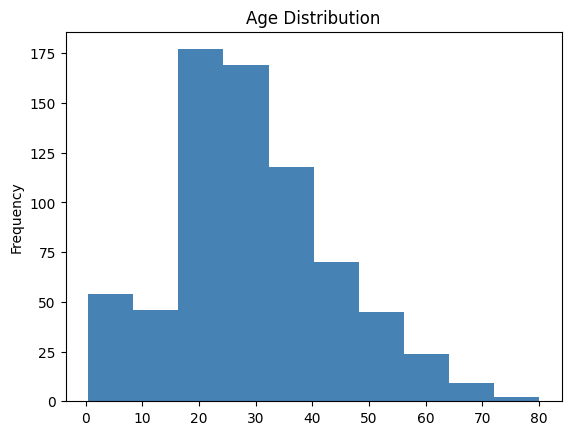

In [22]:
titanic_df['age'].plot.hist(color='steelblue', title='Age Distribution')

<Axes: title={'center': 'Siblings/Spouses Aboard Distribution'}, ylabel='Frequency'>

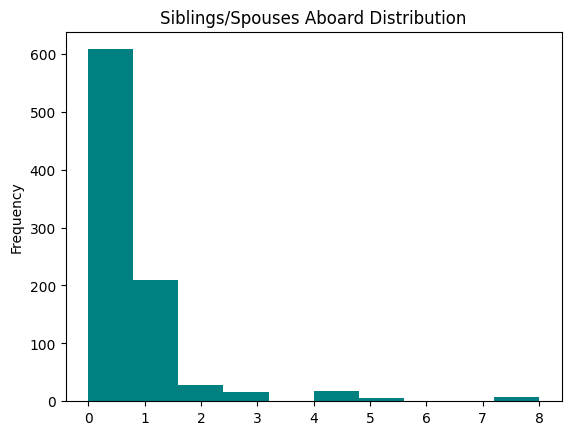

In [23]:
titanic_df['siblings_spouses_aboard'].plot.hist(color='teal', title='Siblings/Spouses Aboard Distribution')

<Axes: title={'center': 'Parents/Children Aboard Distribution'}, ylabel='Frequency'>

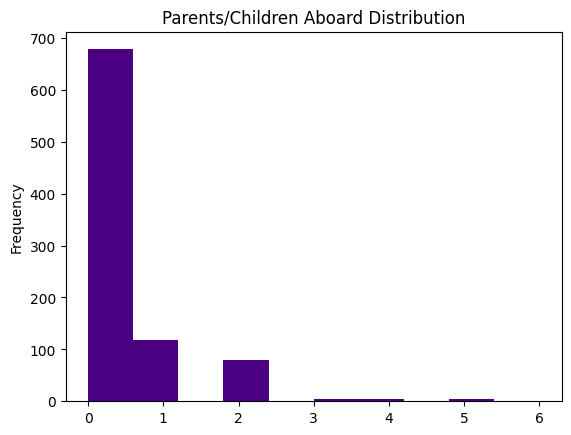

In [24]:
titanic_df['parents_children_aboard'].plot.hist(color='indigo', title='Parents/Children Aboard Distribution')

<Axes: title={'center': 'Fare Distribution'}, ylabel='Frequency'>

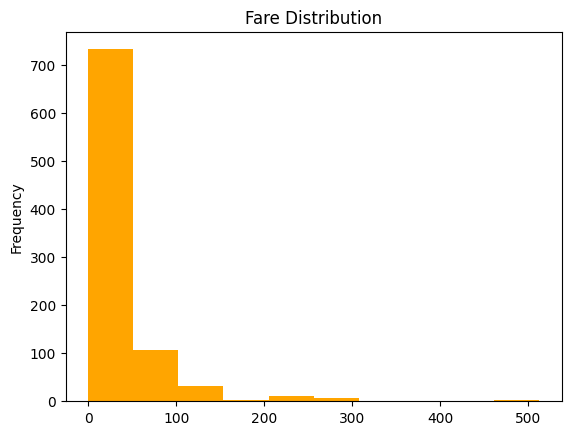

In [25]:
titanic_df['fare'].plot.hist(color='orange', title='Fare Distribution')

<Axes: title={'center': 'Frequency Counts'}, xlabel='sex'>

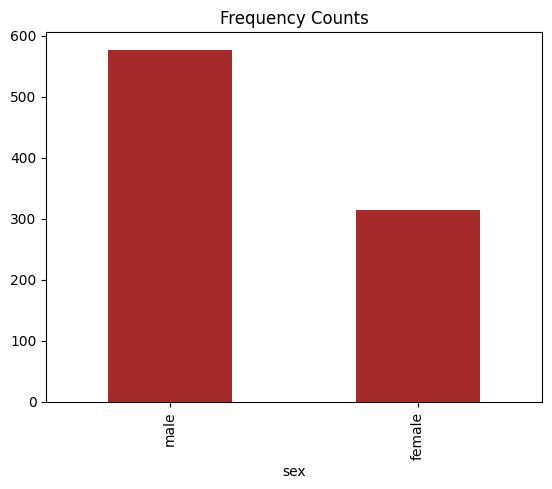

In [26]:
titanic_df['sex'].value_counts().plot.bar(color="brown", title="Frequency Counts")

<Axes: title={'center': 'Class Value Counts'}, xlabel='class'>

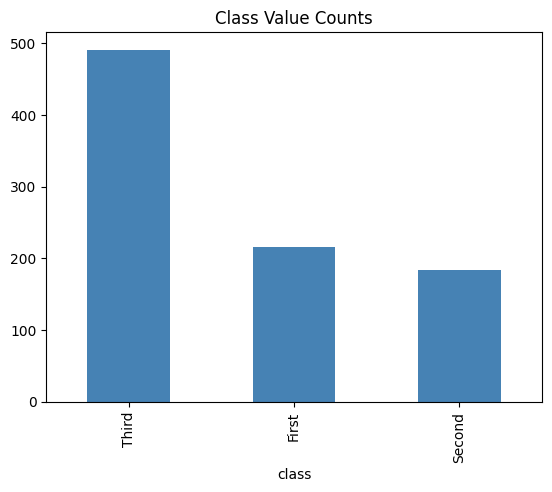

In [27]:
titanic_df['class'].value_counts().plot.bar(color='steelblue', title='Class Value Counts')

<Axes: title={'center': 'Embark Town Value Counts'}, xlabel='embark_town'>

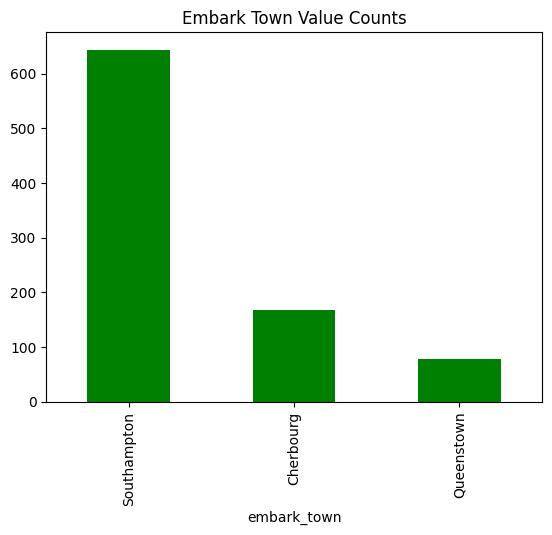

In [28]:
titanic_df['embark_town'].value_counts().plot.bar(color="green", title="Embark Town Value Counts")

<Axes: title={'center': 'Survival Value Counts'}, xlabel='survived'>

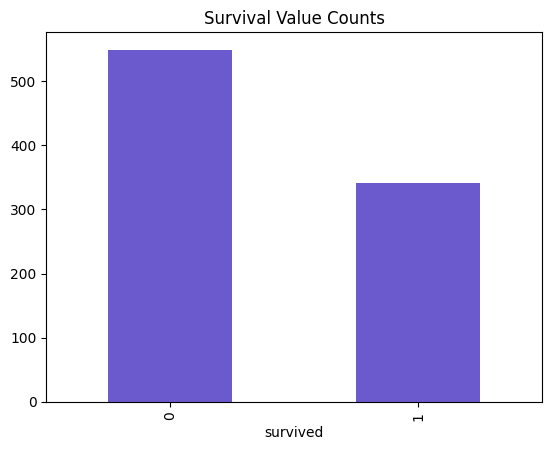

In [29]:
titanic_df['survived'].value_counts(sort=False).plot.bar(color='slateblue', title='Survival Value Counts')

## 7. Bin size and density

Plot the `fare` histogram four times with `bins=5`, `bins=15`, `bins=15, density=True`, and `bins=500, density=True`. Give each one a title that names its bin/density setting (and a color), so the four are easy to tell apart. **Discuss:** how does bin count change the story the histogram tells? What does `density=True` change on the y-axis?

**Discuss:** more bins reveal finer structure (e.g. the fare spike near 0 and a handful of very expensive outliers) but get noisier and harder to read; too few bins smooth real structure away. `density=True` rescales the y-axis so the total area under the bars sums to 1, instead of showing raw counts -- useful for comparing shape across differently-sized groups, but the y-axis numbers stop being intuitive (they're not percentages).

Text(0.5, 1.0, 'Fare Histogram (bins=5)')

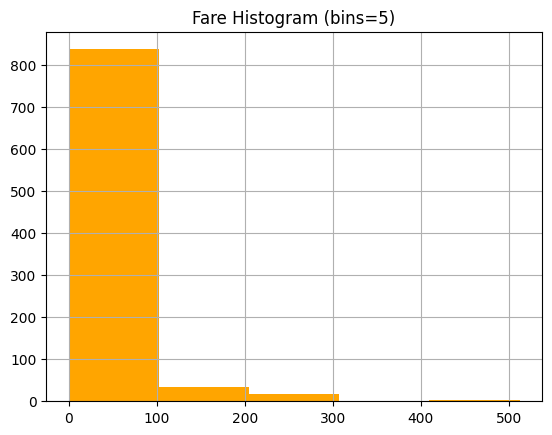

In [ ]:
import matplotlib.pyplot as plt

titanic_df['fare'].hist(bins=5, color='orange')
plt.title('Fare Histogram (bins=5)')

Text(0.5, 1.0, 'Fare Histogram (bins=15)')

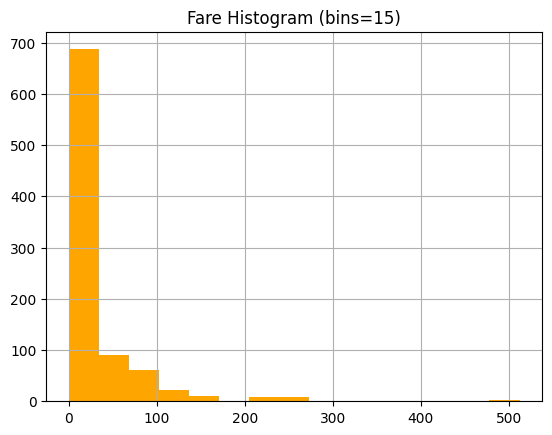

In [ ]:
import matplotlib.pyplot as plt

titanic_df['fare'].hist(bins=15, color='orange')
plt.title('Fare Histogram (bins=15)')

Text(0.5, 1.0, 'Fare Histogram (bins=15, density=True)')

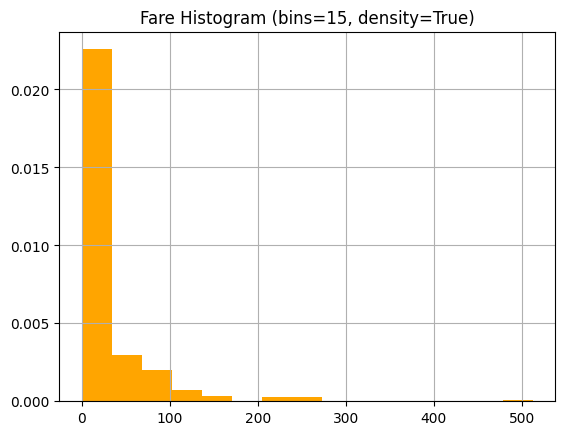

In [ ]:
import matplotlib.pyplot as plt

titanic_df['fare'].hist(bins=15, density=True, color='orange')
plt.title('Fare Histogram (bins=15, density=True)')

Text(0.5, 1.0, 'Fare Histogram (bins=500, density=True)')

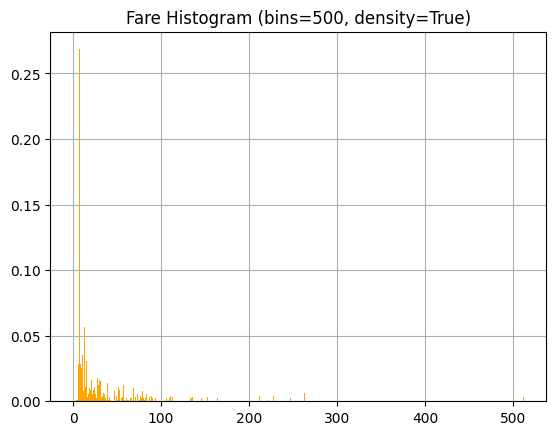

In [ ]:
import matplotlib.pyplot as plt

titanic_df['fare'].hist(bins=500, density=True, color='orange')
plt.title('Fare Histogram (bins=500, density=True)')

## 8. Percentiles and IQR

1. Find the `age` value at the 30th percentile using `.quantile()`. Print it in a formatted sentence.
2. Find the age value at the 75th percentile (Q3) using `.quantile()`.
3. Suppose `age_of_interest = 55`. What percentile rank does that age fall at? (Hint: `(titanic_df['age'].dropna() <= age_of_interest).mean() * 100` — think about why this works.)
4. Save `titanic_df['age'].describe()` into a variable `age_summary`, then compute the IQR as `age_summary['75%'] - age_summary['25%']`.
5. **Optional:** plot the age histogram (30 bins) and draw a vertical dashed line at each of the 13th, 25th, 50th, 75th, and 98th percentiles, labeling each line with its percentile and value. (Hint: loop over the percentiles and use `plt.axvline()` and `plt.text()`.)

In [ ]:
target_percentile = 0.3
value_at_nth = titanic_df['age'].quantile(target_percentile)
print(f"Value at {target_percentile*100}th percentile: {value_at_nth}")


Value at 30.0th percentile: 22.0


In [ ]:
titanic_df[['age']].quantile(.75)


age    38.0
Name: 0.75, dtype: float64

In [ ]:
age_of_interest = 55
# creates a boolean mask of True/False, then takes the average of the 0/1 values
percentile_rank = (titanic_df['age'].dropna() <= age_of_interest).mean() * 100
print(f"{age_of_interest} years old is at the {percentile_rank:.1f}th percentile")


55 years old is at the 94.4th percentile


In [ ]:
age_summary = titanic_df['age'].describe()
iqr = age_summary['75%'] - age_summary['25%']
iqr


np.float64(17.875)

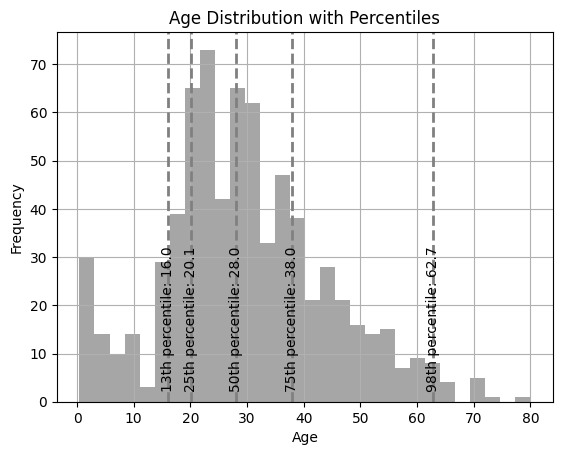

In [ ]:
import matplotlib.pyplot as plt

percentiles = [0.13, 0.25, 0.50, 0.75, 0.98]
percentile_values = titanic_df['age'].quantile(percentiles)

titanic_df['age'].hist(bins=30, alpha=0.7, color='gray')

for pct, value in zip(percentiles, percentile_values):
    plt.axvline(value, color='gray', linestyle='--', linewidth=2)
    plt.text(value, 2, f'{int(pct*100)}th percentile: {value:.1f}',
             rotation=90, verticalalignment='bottom',
             horizontalalignment='center', color='black', fontsize=10)

plt.title("Age Distribution with Percentiles")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


## 9. Boxplots

1. Plot a boxplot of `age` using `.plot.box()`.
2. Plot the same thing using `.boxplot(column='age')` on the DataFrame instead.
3. Plot a boxplot of `age`, split out by `class` (Hint: `.pivot(columns='class', values='age')`, then `.plot.box()`). **Discuss:** what does this tell you about age across classes?

**Discuss:** First class skews older with a higher median age; Third class is younger and more tightly clustered, with more high-age outliers relative to its own spread.

<Axes: >

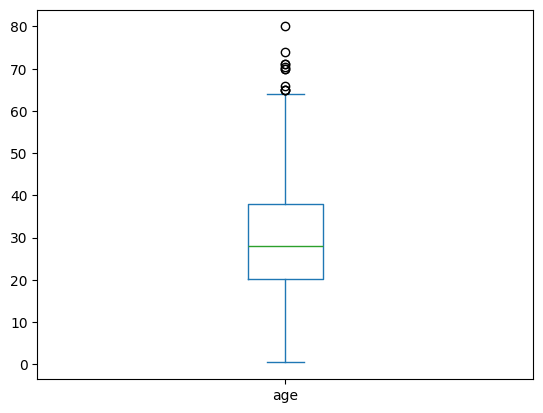

In [ ]:
titanic_df['age'].plot.box()

<Axes: >

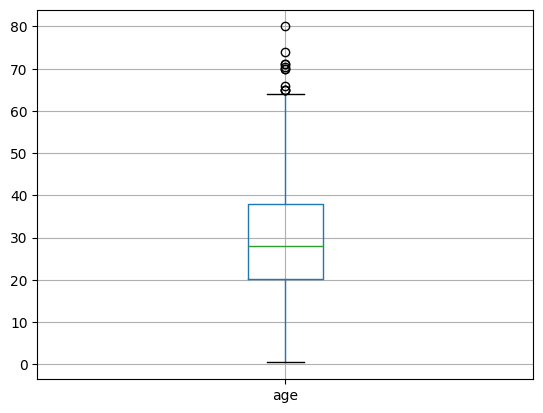

In [ ]:
titanic_df.boxplot(column='age')


<Axes: >

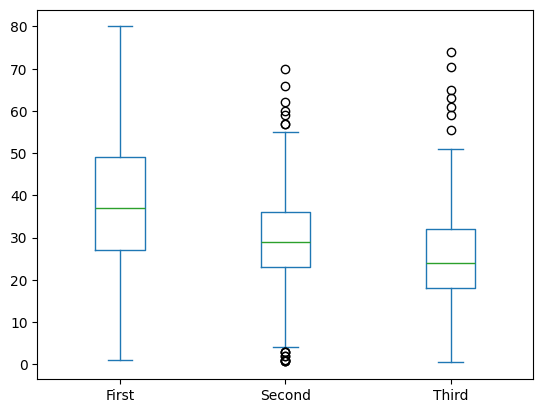

In [ ]:
titanic_df.pivot(columns='class', values='age').plot.box()

## 10. Scatter plots and correlation

1. Make a scatter plot of `age` (x) vs `fare` (y).
2. Use `.query()` to find all passengers with `fare > 400`. Who are they?
3. Compute the correlation between `age` and `fare`.
4. Select only the numeric columns (Hint: `.select_dtypes(include=['number'])`) and compute the full correlation matrix.

<Axes: xlabel='age', ylabel='fare'>

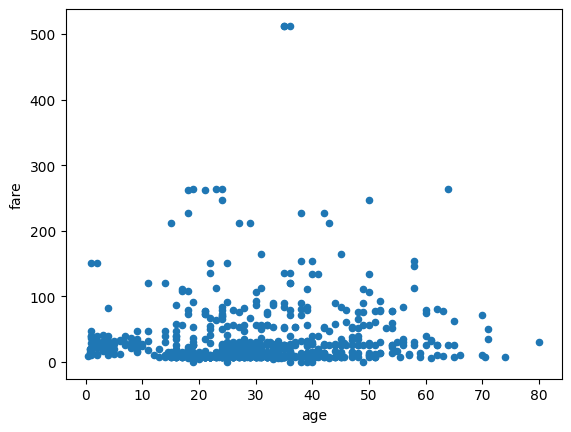

In [ ]:
titanic_df.plot(kind='scatter', x='age', y='fare')


In [ ]:
titanic_df.query("fare > 400")


,passenger_id,survived,sex,age,siblings_spouses_aboard,parents_children_aboard,fare,class,embark_town
258,5ad90b25-4c54-48f8-b3c7-b6376e96d4ee,1,female,35.0,0,0,512.3292,First,Cherbourg
679,51901a0f-b882-4ce5-9f1d-df726dfc52cb,1,male,36.0,0,1,512.3292,First,Cherbourg
737,939c7a36-01ef-47e4-a1a4-fa6baee95cf7,1,male,35.0,0,0,512.3292,First,Cherbourg


In [ ]:
titanic_df['age'].corr(titanic_df['fare'])


np.float64(0.09606669176903891)

In [ ]:
numeric_df = titanic_df.select_dtypes(include=['number'])
numeric_df.corr()


,survived,age,siblings_spouses_aboard,parents_children_aboard,fare
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067
siblings_spouses_aboard,-0.035322,-0.308247,1.000000,0.414838,0.159651
parents_children_aboard,0.081629,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,0.096067,0.159651,0.216225,1.000000


## 11. Dummy variables and a correlation heatmap

1. Use `pd.get_dummies()` to one-hot encode `sex`, `class`, and `embark_town` into a new DataFrame `titanic_dummies`.
2. Compute the correlation matrix of `titanic_dummies` and save it as `correlation_matrix`.
3. Visualize `correlation_matrix` as a heatmap with `seaborn` (`sns.heatmap`). Show the correlation values on the cells (`annot=True`), use a diverging colormap centered at 0 (e.g. `cmap='RdBu_r', center=0`), and give the plot a title.

**Watch out:** `titanic_dummies` still has `passenger_id`, a string/ID column. On the pandas version we're using, `.corr()` will error on it (`could not convert string to float`) unless you pass `numeric_only=True`.

In [ ]:
titanic_dummies = pd.get_dummies(titanic_df, columns=['sex', 'class', 'embark_town'])
titanic_dummies


,passenger_id,survived,age,siblings_spouses_aboard,parents_children_aboard,fare,sex_female,sex_male,class_First,class_Second,class_Third,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,af1089fa-c928-4719-94ec-4bdb0aa90e8a,0,22.0,1,0,7.2500,False,True,False,False,True,False,False,True
1,5f616a6d-f338-4360-9d7b-3b92196dd350,1,38.0,1,0,71.2833,True,False,True,False,False,True,False,False
2,34ad8431-f090-40d0-a1c9-50fe2cb39979,1,26.0,0,0,7.9250,True,False,False,False,True,False,False,True
3,3bcdceb3-f1dd-4ef2-a9dc-089c13f54a27,1,35.0,1,0,53.1000,True,False,True,False,False,False,False,True
4,0ee5b915-66c7-42d4-ba2d-5c0703633ccc,0,35.0,0,0,8.0500,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,79e179d2-8fd2-42e3-8e25-6d1124861a45,0,27.0,0,0,13.0000,False,True,False,True,False,False,False,True
887,a53b93a9-a0fe-4e83-ac58-a74c32825abe,1,19.0,0,0,30.0000,True,False,True,False,False,False,False,True
888,c89d25cf-49ac-4aaf-a614-b2cf8754bc13,0,NaN,1,2,23.4500,True,False,False,False,True,False,False,True
889,2094390f-10db-4ca3-9693-ef5795da5446,1,26.0,0,0,30.0000,False,True,True,False,False,True,False,False


In [ ]:
# numeric_only=True excludes passenger_id (a string identifier, not a feature)
correlation_matrix = titanic_dummies.corr(numeric_only=True)
correlation_matrix


,survived,age,siblings_spouses_aboard,parents_children_aboard,fare,sex_female,sex_male,class_First,class_Second,class_Third,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307,0.543351,-0.543351,0.285904,0.093349,-0.322308,0.168240,0.003650,-0.155660
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067,-0.093254,0.093254,0.348941,0.006954,-0.312271,0.036261,-0.022405,-0.032523
siblings_spouses_aboard,-0.035322,-0.308247,1.000000,0.414838,0.159651,0.114631,-0.114631,-0.054582,-0.055932,0.092548,-0.059528,-0.026354,0.070941
parents_children_aboard,0.081629,-0.189119,0.414838,1.000000,0.216225,0.245489,-0.245489,-0.017633,-0.000734,0.015790,-0.011069,-0.081228,0.063036
fare,0.257307,0.096067,0.159651,0.216225,1.000000,0.182333,-0.182333,0.591711,-0.118557,-0.413333,0.269335,-0.117216,-0.166603
sex_female,0.543351,-0.093254,0.114631,0.245489,0.182333,1.000000,-1.000000,0.098013,0.064746,-0.137143,0.082853,0.074115,-0.125722
sex_male,-0.543351,0.093254,-0.114631,-0.245489,-0.182333,-1.000000,1.000000,-0.098013,-0.064746,0.137143,-0.082853,-0.074115,0.125722
class_First,0.285904,0.348941,-0.054582,-0.017633,0.591711,0.098013,-0.098013,1.000000,-0.288585,-0.626738,0.296423,-0.155342,-0.170379
class_Second,0.093349,0.006954,-0.055932,-0.000734,-0.118557,0.064746,-0.064746,-0.288585,1.000000,-0.565210,-0.125416,-0.127301,0.192061
class_Third,-0.322308,-0.312271,0.092548,0.015790,-0.413333,-0.137143,0.137143,-0.626738,-0.565210,1.000000,-0.153329,0.237449,-0.009511


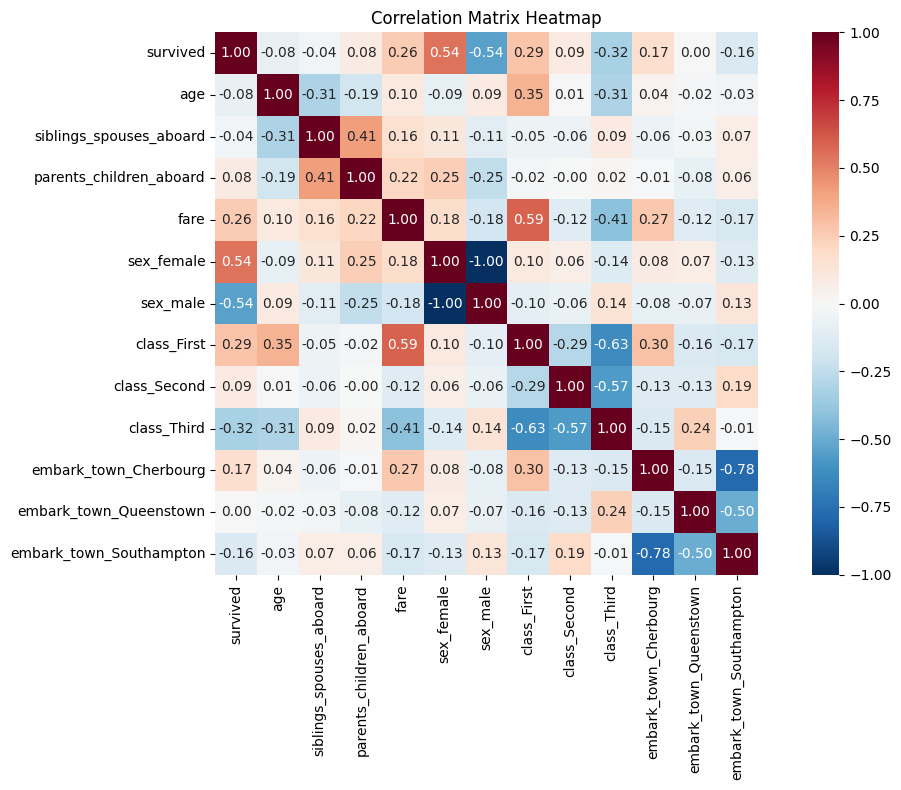

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


## 12. Cross-tabulations

1. Make a scatter plot of `siblings_spouses_aboard` vs `parents_children_aboard`, with `alpha=0.1` and `s=50` so overlapping points are visible.
2. Get value counts for the combination of `sex` and `class`.
3. Build a cross-tab of `sex` (rows) by `class` (columns) — raw counts.
4. Rebuild it with `margins=True` to add row/column totals.
5. Rebuild it three more times, each `* 100` and rounded to 1 decimal, using `normalize='all'`, `normalize='columns'`, and `normalize='index'`. **Discuss:** what question does each of the three answer?
6. Plot the sex-by-class cross-tab (counts, no margins) as a grouped bar chart, with a title.

**Discuss:** `normalize='all'` gives each cell's share of *every* passenger (the whole table sums to 100%); `normalize='columns'` gives each cell's share *within its class* (each class column sums to 100%, answering "of First class, what % is female?"); `normalize='index'` gives each cell's share *within its sex* (each sex row sums to 100%, answering "of women, what % rode First class?").

<Axes: xlabel='siblings_spouses_aboard', ylabel='parents_children_aboard'>

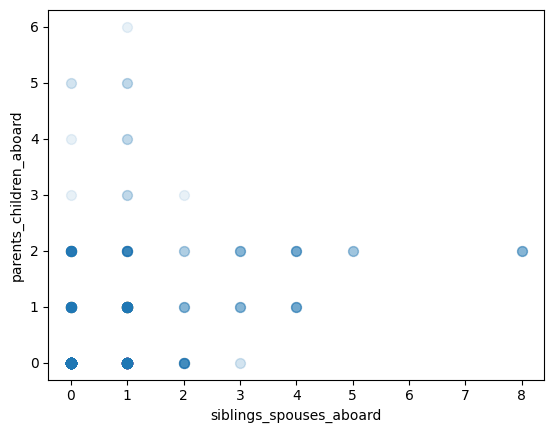

In [ ]:
titanic_df.plot(kind='scatter', x='siblings_spouses_aboard', y='parents_children_aboard',
                 alpha=0.1, s=50)


In [ ]:
titanic_df[['sex', 'class']].value_counts()


sex     class 
male    Third     347
female  Third     144
male    First     122
        Second    108
female  First      94
        Second     76
Name: count, dtype: int64

In [ ]:
pd.crosstab(titanic_df['sex'], titanic_df['class'])


class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


In [ ]:
pd.crosstab(titanic_df['sex'], titanic_df['class'], margins=True)


class,First,Second,Third,All
sex,,,,
female,94,76,144,314
male,122,108,347,577
All,216,184,491,891


In [ ]:
percent_of_total = (pd.crosstab(titanic_df['sex'], titanic_df['class'],
                                 margins=True, normalize='all') * 100).round(1)
percent_of_total


class,First,Second,Third,All
sex,,,,
female,10.5,8.5,16.2,35.2
male,13.7,12.1,38.9,64.8
All,24.2,20.7,55.1,100.0


In [ ]:
percent_of_column = (pd.crosstab(titanic_df['sex'], titanic_df['class'],
                                  margins=True, normalize='columns') * 100).round(1)
percent_of_row = (pd.crosstab(titanic_df['sex'], titanic_df['class'],
                               margins=True, normalize='index') * 100).round(1)
display(percent_of_column)
display(percent_of_row)


class,First,Second,Third,All
sex,,,,
female,43.5,41.3,29.3,35.2
male,56.5,58.7,70.7,64.8


class,First,Second,Third
sex,,,
female,29.9,24.2,45.9
male,21.1,18.7,60.1
All,24.2,20.7,55.1


<Axes: title={'center': 'Sex by Class'}, xlabel='sex'>

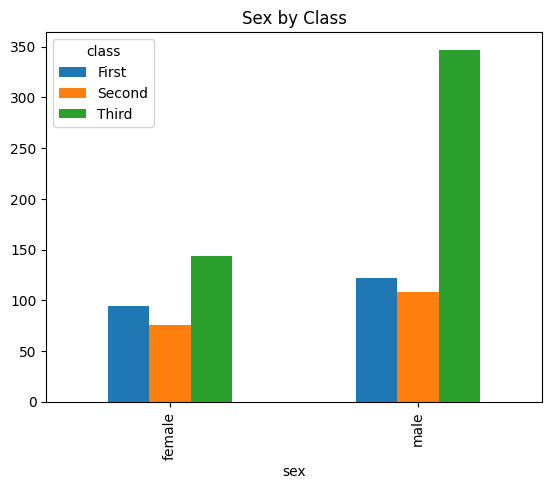

In [ ]:
pd.crosstab(titanic_df['sex'], titanic_df['class']).plot(kind='bar', title='Sex by Class')

**Optional:** side-by-side heatmaps, counts vs. percent of total.

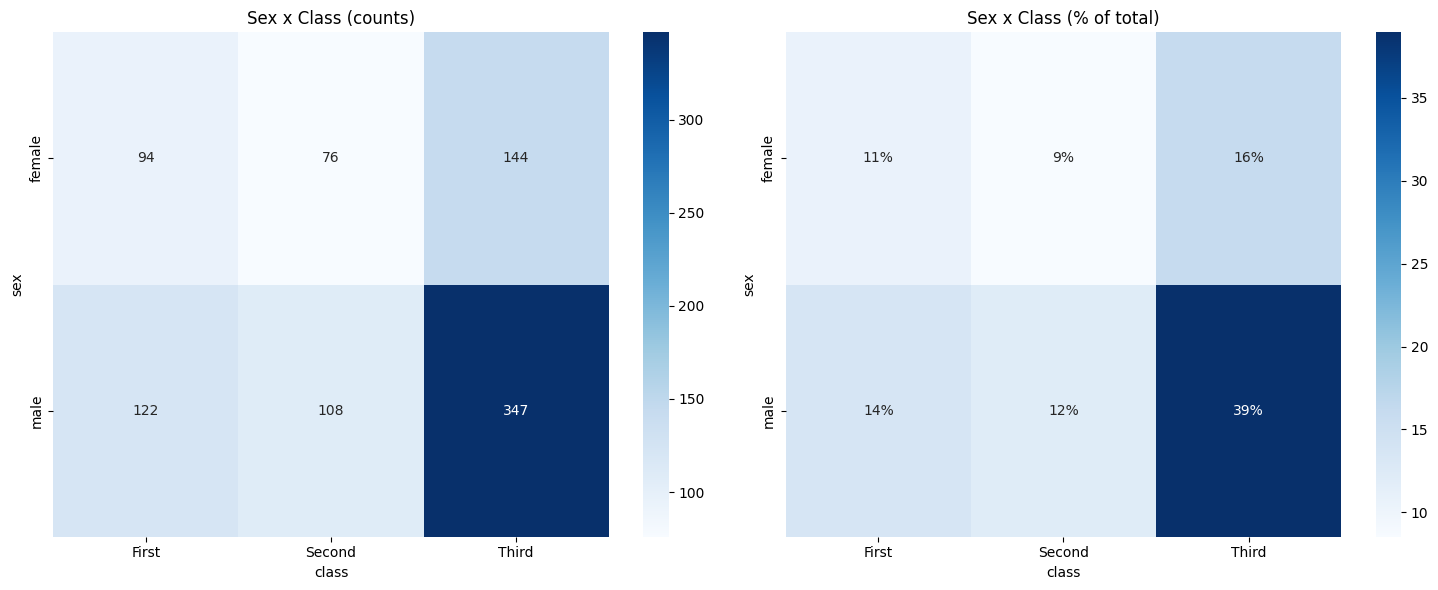

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

crosstab_counts = pd.crosstab(titanic_df['sex'], titanic_df['class'])
crosstab_percent = pd.crosstab(titanic_df['sex'], titanic_df['class'], normalize='all') * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(crosstab_counts, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Sex x Class (counts)')

sns.heatmap(crosstab_percent, annot=True, fmt='.0f', cmap='Blues', ax=ax2)
for text in ax2.texts:
    text.set_text(text.get_text() + '%')
ax2.set_title('Sex x Class (% of total)')

plt.tight_layout()
plt.show()


## 13. Survival analysis

This is the question the dataset is actually famous for. Put the crosstab/groupby tools from the last section to work on `survived` instead of just describing it.

1. Compute the overall survival rate as a percent (Hint: `.mean() * 100` on the `survived` column, since it's 0/1).
2. Cross-tab `sex` by `survived`, normalized by `index` (row) and shown as a percent — this gives the survival rate *within* each sex.
3. Do the same for `class` by `survived`.
4. **Optional:** create an `age_group` column by binning `age` into `[0, 12, 19, 59, 100]` labeled `["child", "teen", "adult", "senior"]` with `pd.cut()`, then compute survival rate by `age_group` the same way.
5. **Discuss:** in 2-3 sentences, what pattern do you see across sex, class, and age? Does it match the 'women and children first' story?

In [ ]:
overall_survival_rate = titanic_df['survived'].mean() * 100
print(f"Overall survival rate: {overall_survival_rate:.1f}%")


Overall survival rate: 38.4%


In [ ]:
(pd.crosstab(titanic_df['sex'], titanic_df['survived'], normalize='index') * 100).round(1)


survived,0,1
sex,,
female,25.8,74.2
male,81.1,18.9


In [ ]:
(pd.crosstab(titanic_df['class'], titanic_df['survived'], normalize='index') * 100).round(1)


survived,0,1
class,,
First,37.0,63.0
Second,52.7,47.3
Third,75.8,24.2


In [ ]:
age_group = pd.cut(titanic_df['age'], bins=[0, 12, 19, 59, 100],
                    labels=["child", "teen", "adult", "senior"])
(pd.crosstab(age_group, titanic_df['survived'], normalize='index') * 100).round(1)


survived,0,1
age,,
child,42.0,58.0
teen,58.9,41.1
adult,61.1,38.9
senior,73.1,26.9


*Discussion:* Yes -- this matches "women and children first" closely. Women survived at ~74% vs. ~19% for men, a huge gap. Class also matters a lot on its own: First class survival is ~63% vs. ~24% in Third, likely reflecting both cabin/deck location and who got priority at the lifeboats. Age shows a milder version of the same pattern -- children survived at the highest rate (~58%), declining through teens, adults, and seniors (~27%) -- consistent with children being prioritized, but the effect is smaller than sex and gets tangled up with class (e.g. more children traveled in lower classes).

## 14. Feature engineering

Raw columns aren't always the most useful ones for analysis. Create a few new columns:

1. `family_size`: `siblings_spouses_aboard + parents_children_aboard + 1` (the `+1` counts the passenger themself).
2. `is_alone`: `True` if `family_size == 1`, else `False`.
3. Compare survival rate for `is_alone` vs. not, the same way you did in section 13 (crosstab or groupby, normalized to a percent). **Discuss:** does traveling alone matter?
4. **Optional:** create `fare_per_person` = `fare / family_size`. How does its distribution (`.describe()` or a histogram) compare to the raw `fare` column?

In [ ]:
titanic_df['family_size'] = (titanic_df['siblings_spouses_aboard']
                              + titanic_df['parents_children_aboard'] + 1)


In [ ]:
titanic_df['is_alone'] = titanic_df['family_size'] == 1


In [ ]:
(pd.crosstab(titanic_df['is_alone'], titanic_df['survived'], normalize='index') * 100).round(1)


survived,0,1
is_alone,,
False,49.4,50.6
True,69.6,30.4


*Discussion:* Yes -- passengers traveling alone survived at ~30%, vs. ~51% for those with family aboard. Being alone is correlated with lower survival, though part of this is likely confounded with class, sex, and age (e.g. solo travelers skew more male).

In [ ]:
titanic_df['fare_per_person'] = titanic_df['fare'] / titanic_df['family_size']

display(titanic_df['fare'].describe())
display(titanic_df['fare_per_person'].describe())


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

count    891.000000
mean      19.916375
std       35.841257
min        0.000000
25%        7.250000
50%        8.300000
75%       23.666667
max      512.329200
Name: fare_per_person, dtype: float64

## 15. Group-by aggregation

Group `titanic_df` by `class` and compute, in a single `.agg()` call:
- the count and mean of `age`
- the mean of `fare`

Round the result to 1 decimal place.
- Chain `.round(1)` onto the end of the whole `.agg(...)` call to round every value in the result at once.

In [ ]:
titanic_df.groupby('class').agg({
    'age': ['count', 'mean'],
    'fare': 'mean'
}).round(1)


age        fare
       count  mean  mean
class                   
First    186  38.2  84.2
Second   173  29.9  20.7
Third    355  25.1  13.7